## Imports
Libraries for data manipulation, preprocessing, clustering and statistics.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, unicodedata
import json
import sklearn

from scipy import stats
from scipy.spatial.distance import cdist
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 800
pd.set_option("display.max_columns", 50)

maroon_cmap = LinearSegmentedColormap.from_list('maroon_theme', ['white', '#591427'])

## Data loading and cleaning
Loads the mobility dataset, harmonizes country names, and normalizes the *Fewer Opportunities* column into Yes/No/Unknown.

In [2]:
mob = pd.read_csv("mobility_dataset_sample.csv")

def clean_fewer_opportunities(v):
    v = str(v).strip().lower()
    return {"yes": "Yes", "1": "Yes", "no": "No", "0": "No"}.get(v, "Unknown")

mob["Fewer_Opportunities_clean"] = mob["Fewer Opportunities"].apply(clean_fewer_opportunities)
mob.drop(columns=["Fewer Opportunities"], inplace=True)
mob.rename(columns={"Fewer_Opportunities_clean": "Fewer Opportunities"}, inplace=True)
mob.head()

,Academic Year,Mobility Duration,Field of Education,Participant Country,Education Level,Participant Gender,Participant Age,Sending Country,Sending Country HICP,Sending City,Sending Organization,Sending Institution Rank,Receiving Country,Receiving Country HICP,Receiving City,Receiving Organization,Receiving Institution Rank,Fewer Opportunities
0,2019,76,Biology,Germany,Bachelor,Other,35,Germany,108.3,Hamburg,Hamburg University,605,Italy,105.4,Milan,Milan Business School,33,No
1,2022,313,Business Administration,Italy,Master,Other,35,Italy,105.4,Milan,Milan Business School,226,France,106.2,Lyon,Lyon Business School,604,No
2,2021,179,Law,Belgium,Master,Male,28,Belgium,107.6,Brussels,Brussels University,95,Finland,105.9,Tampere,Tampere Business School,100,No
3,2020,27,Biology,Romania,Short Cycle,Other,30,Romania,118.5,Timisoara,Timisoara University,566,Hungary,116.3,Gyor,Gyor Polytechnic,850,Yes
4,2018,343,Medicine,Romania,PhD,Male,21,Romania,118.5,Cluj-Napoca,Cluj-Napoca Business School,285,Austria,108.9,Vienna,Vienna Business School,651,No


## Feature engineering — field of study
Maps raw *Field of Education* values onto the 10 ISCED-F macro-fields, to avoid an overly sparse one-hot encoding.


In [3]:
with open('mapping_results.json', 'r') as map:
    mapping_data = json.load(map)

In [4]:
mob.shape

(100, 18)

## Feature engineering — HICP and country frequency
Winsorizes the HICP index (to limit the effect of Türkiye-related outliers), computes the sending/receiving differential, and the frequency of each country in the sample.

In [5]:
mob2 = mob.copy()
mob2["HICP diff"] = mob2["Receiving Country HICP"] - mob2["Sending Country HICP"]

mob2.head()

,Academic Year,Mobility Duration,Field of Education,Participant Country,Education Level,Participant Gender,Participant Age,Sending Country,Sending Country HICP,Sending City,Sending Organization,Sending Institution Rank,Receiving Country,Receiving Country HICP,Receiving City,Receiving Organization,Receiving Institution Rank,Fewer Opportunities,HICP diff
0,2019,76,Biology,Germany,Bachelor,Other,35,Germany,108.3,Hamburg,Hamburg University,605,Italy,105.4,Milan,Milan Business School,33,No,-2.9
1,2022,313,Business Administration,Italy,Master,Other,35,Italy,105.4,Milan,Milan Business School,226,France,106.2,Lyon,Lyon Business School,604,No,0.8
2,2021,179,Law,Belgium,Master,Male,28,Belgium,107.6,Brussels,Brussels University,95,Finland,105.9,Tampere,Tampere Business School,100,No,-1.7
3,2020,27,Biology,Romania,Short Cycle,Other,30,Romania,118.5,Timisoara,Timisoara University,566,Hungary,116.3,Gyor,Gyor Polytechnic,850,Yes,-2.2
4,2018,343,Medicine,Romania,PhD,Male,21,Romania,118.5,Cluj-Napoca,Cluj-Napoca Business School,285,Austria,108.9,Vienna,Vienna Business School,651,No,-9.6


## Split into categorical and numerical columns

In [6]:
student_num_cols = ["Mobility Duration", "Participant Age", "Sending Country HICP", "Receiving Country HICP", "Sending Institution Rank", "Receiving Institution Rank"]
student_cat_cols = ["Participant Gender", "Fewer Opportunities", "Education Level", "Field of Education"]


# features used for external validation >:3
eta_cols = student_num_cols + ["HICP diff"]
mob2[eta_cols] = mob2[eta_cols].fillna(mob2[eta_cols].median())
print(mob2[eta_cols].isna().sum())

Mobility Duration             0
Participant Age               0
Sending Country HICP          0
Receiving Country HICP        0
Sending Institution Rank      0
Receiving Institution Rank    0
HICP diff                     0
dtype: int64


## Weighted preprocessing pipeline
Defines a function that builds the feature matrix by scaling/one-hot-encoding each block with a configurable weight. We use a single **baseline** weighting (equal weight to numerical and categorical blocks).

In [7]:
mob3 = mob2
mob3.shape

(100, 19)

In [8]:
from scipy.sparse import issparse

def build_matrix(weights):
    ct = ColumnTransformer([
        ("student_num", StandardScaler(), student_num_cols),
        ("student_cat", OneHotEncoder(handle_unknown="infrequent_if_exist"), student_cat_cols),
    ], transformer_weights=weights)

    Xt = ct.fit_transform(mob3)
    if issparse(Xt):
        Xt = Xt.toarray()

    feature_names = ct.get_feature_names_out()
    return Xt, feature_names

version = {
    "baseline": {"student_num": 1, "student_cat": 1},
}

In [9]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

## Elbow and silhouette methods
Scans k=2, ..., 10 with elbow and silhouette, automatically picks the best k (excluding k=2, which only isolates outliers) and trains the final KMeans.

c:\Users\User\anaconda3\envs\geo\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\User\anaconda3\envs\geo\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\User\anaconda3\envs\geo\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\User\anaconda3\envs\geo\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known

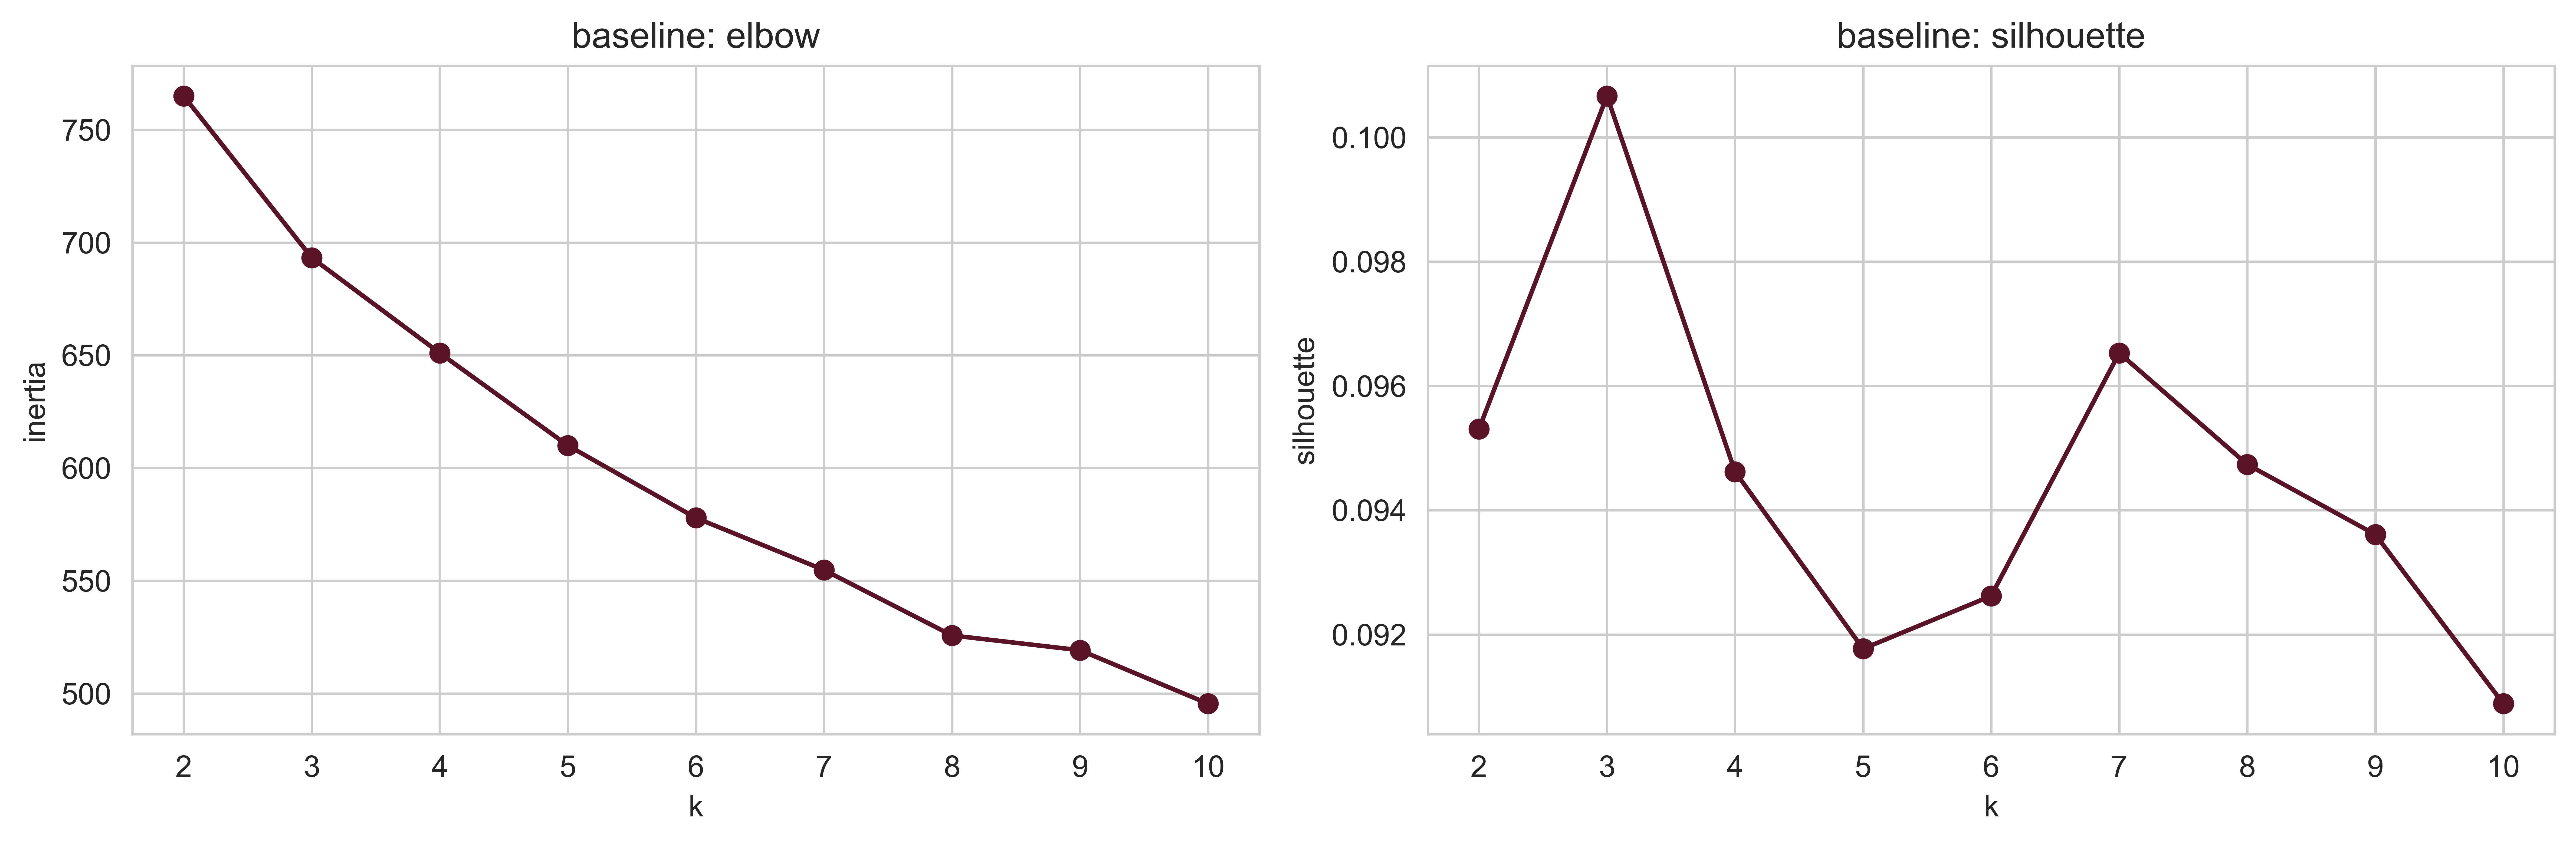

baseline: best_k=3, silhouette=0.101


c:\Users\User\anaconda3\envs\geo\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [10]:
name = "baseline"
w = version[name]
Xt, feat_names = build_matrix(w)
inertias, sils = [], []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Xt)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Xt, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker="o", color="#591427")
axes[0].set_title(f"{name}: elbow")
axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia")

axes[1].plot(list(k_range), sils, marker="o", color="#591427")
axes[1].set_title(f"{name}: silhouette")
axes[1].set_xlabel("k"); axes[1].set_ylabel("silhouette")

plt.tight_layout()
plt.savefig(f"clustering_predict_{name}_{mob3.shape[0]}.png", dpi=800)
plt.show()

best_k = list(k_range)[int(np.argmax(sils[1:])) + 1]
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_final = km_final.fit_predict(Xt)
sil_final = silhouette_score(Xt, labels_final)

results = {name: {"X": Xt, "feature_names": feat_names, "k": best_k, "labels": labels_final, "silhouette": sil_final}}
print(f"{name}: best_k={best_k}, silhouette={sil_final:.3f}")

## Cluster separation in feature space

PC1 (15.8% of variance) is dominated by: student_num__Receiving Country HICP
PC2 (14.2% of variance) is dominated by: student_num__Mobility Duration


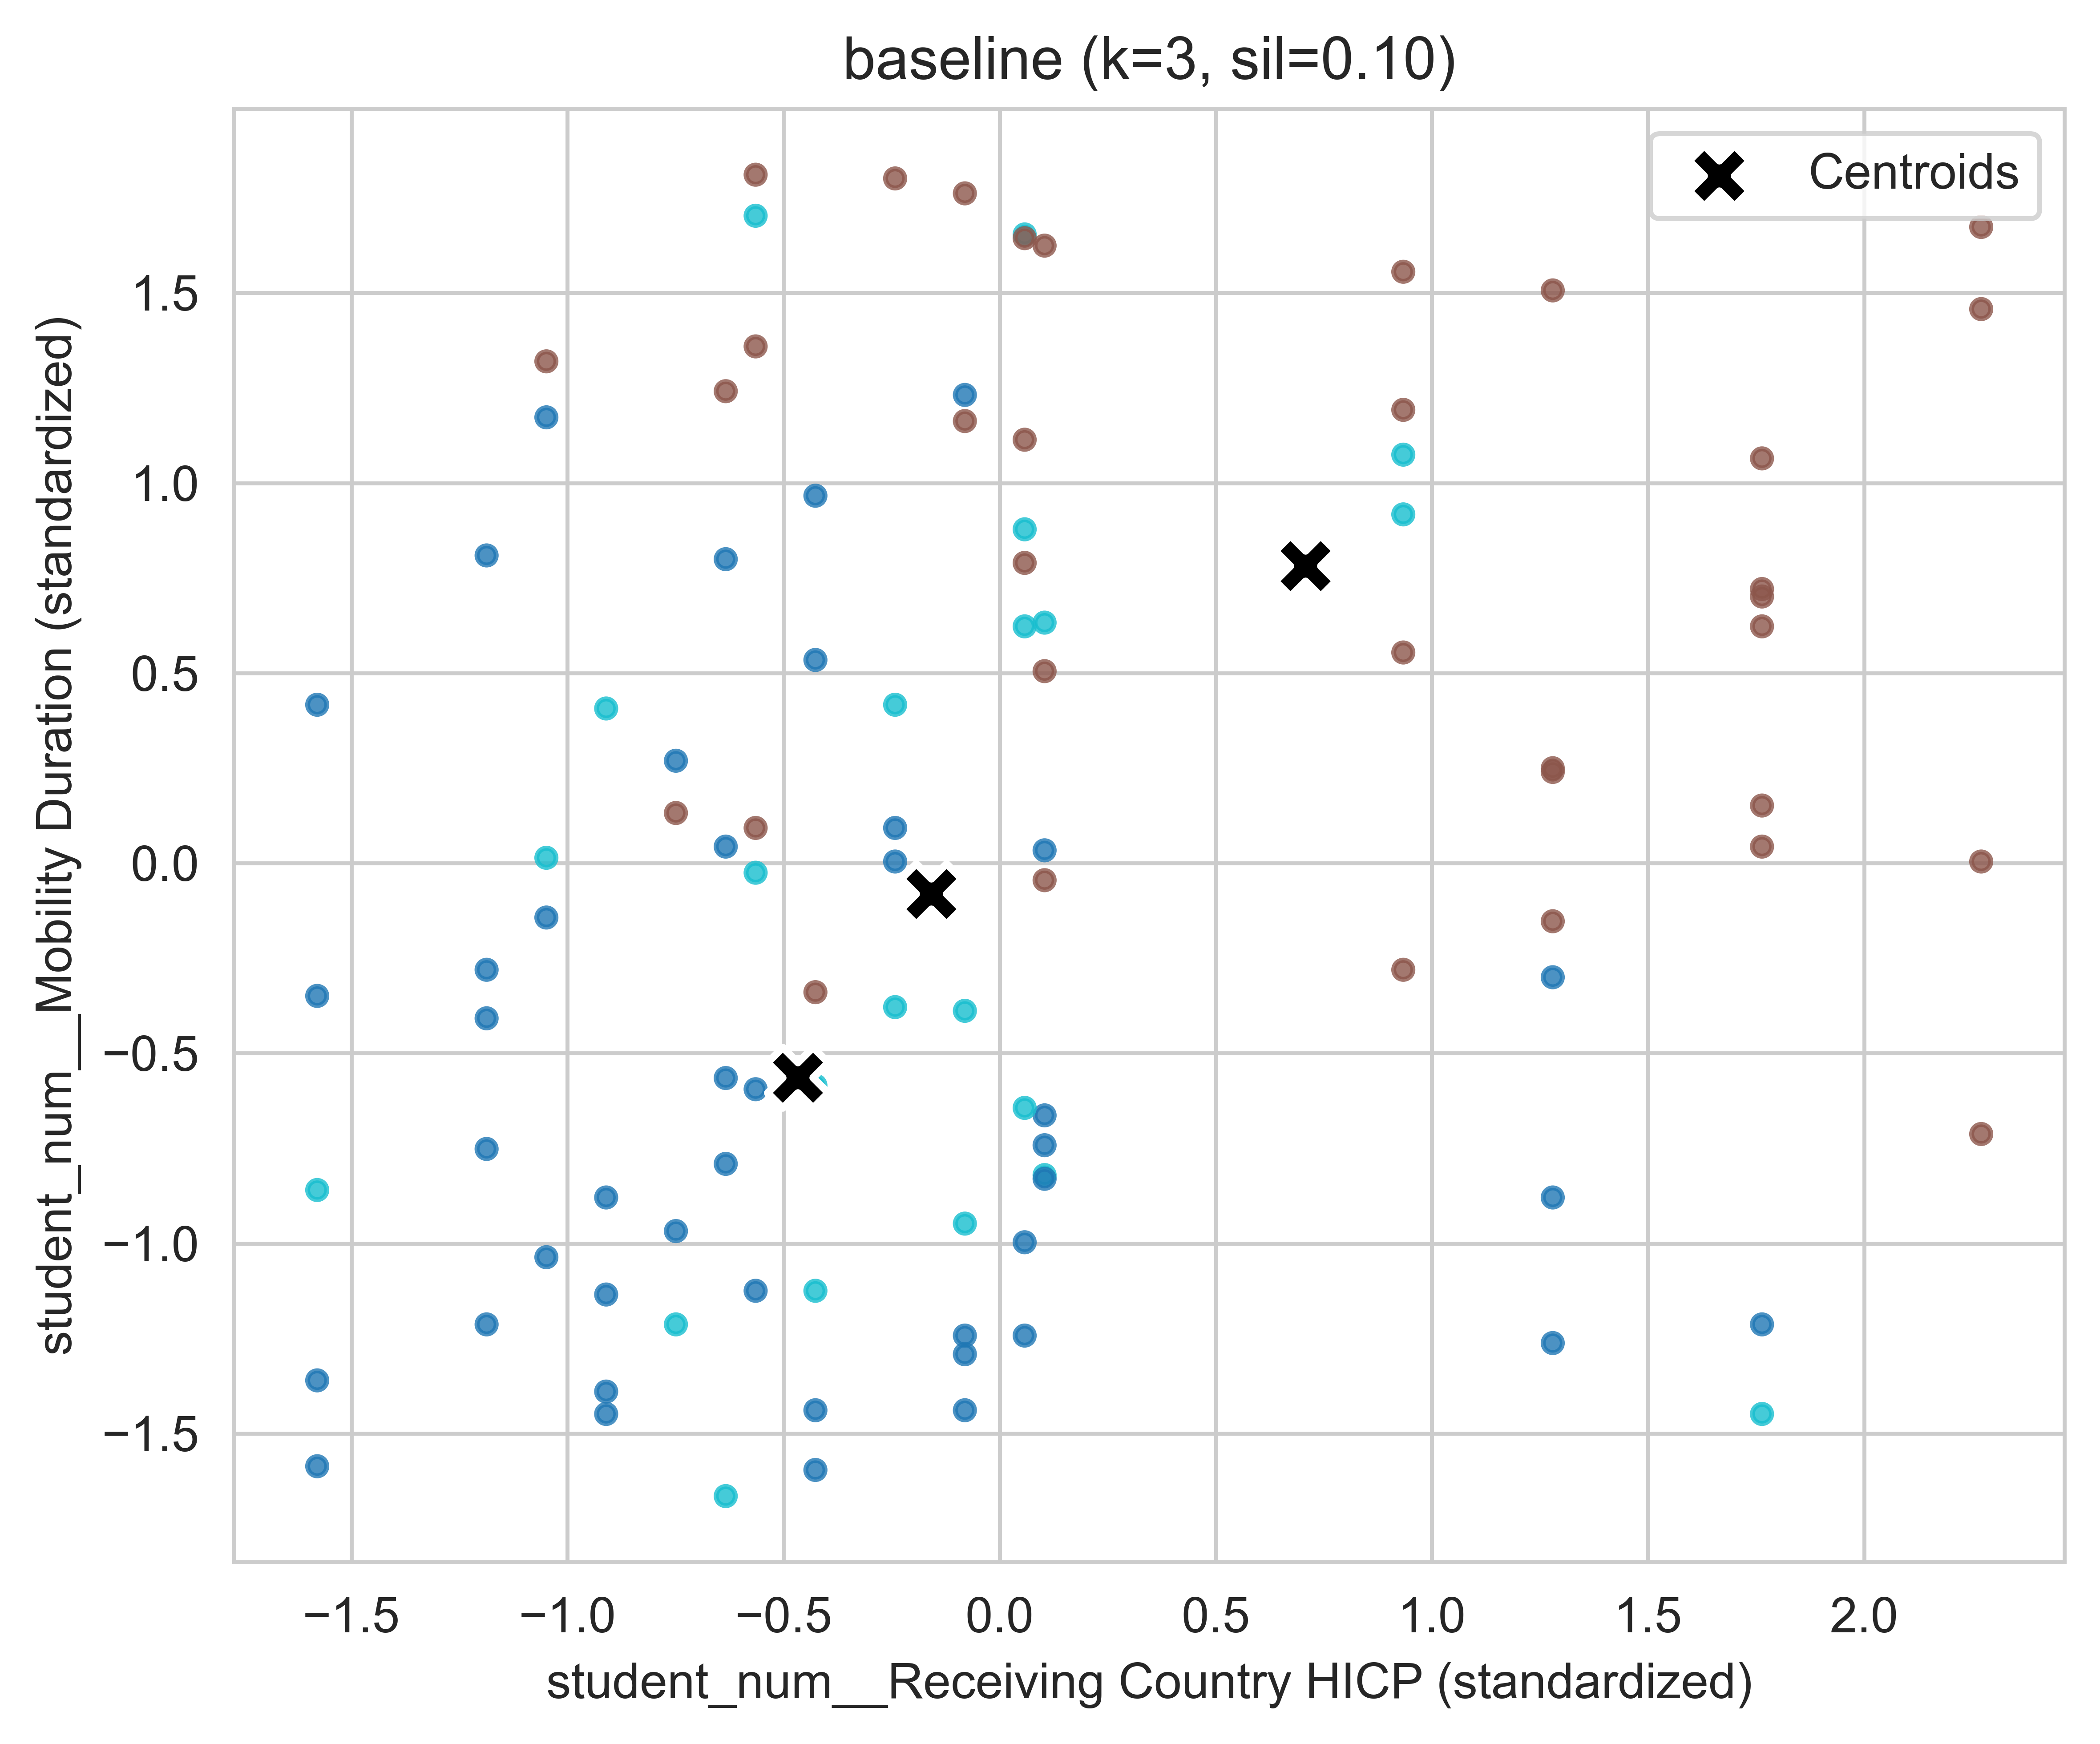

In [11]:
name, r = next(iter(results.items()))
X_df = pd.DataFrame(r["X"], columns=r["feature_names"])
pca = PCA(n_components=2, random_state=42)
pca.fit(X_df)
k_r, sil_r = r["k"], r["silhouette"]

feat_names_in = pca.feature_names_in_
loadings = pca.components_
top_pc1 = feat_names_in[np.argmax(np.abs(loadings[0]))]
top_pc2 = feat_names_in[np.argmax(np.abs(loadings[1]))]
var_ratio = pca.explained_variance_ratio_
print(f"PC1 ({var_ratio[0]:.1%} of variance) is dominated by: {top_pc1}")
print(f"PC2 ({var_ratio[1]:.1%} of variance) is dominated by: {top_pc2}")

# Plot directly on these two original features (real variables), not on the PCA-combined axes
x_vals = X_df[top_pc1].values
y_vals = X_df[top_pc2].values

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(x_vals, y_vals, c=r["labels"], cmap="tab10", s=15, alpha=0.8)

centroids = np.array([
    [x_vals[r["labels"] == i].mean(), y_vals[r["labels"] == i].mean()]
    for i in range(k_r)
])
ax.scatter(centroids[:, 0], centroids[:, 1], c="black", marker="X", s=150,
           edgecolor="white", linewidth=1.5, label="Centroids")
ax.legend()

ax.set_xlabel(f"{top_pc1} (standardized)")
ax.set_ylabel(f"{top_pc2} (standardized)")
ax.set_title(f"{name} (k={k_r}, sil={sil_r:.2f})")
plt.tight_layout()
plt.savefig("clustering_comparison.png", dpi=800)
plt.show()

## Cluster assignment
Only one version (baseline) is used, so its labels are assigned directly to the main dataframe — no comparison across versions is needed.

In [12]:
mob3["cluster"] = results["baseline"]["labels"]

## Per-sample silhouette plot
Shows the distribution of silhouette coefficients per individual sample, grouped by cluster.

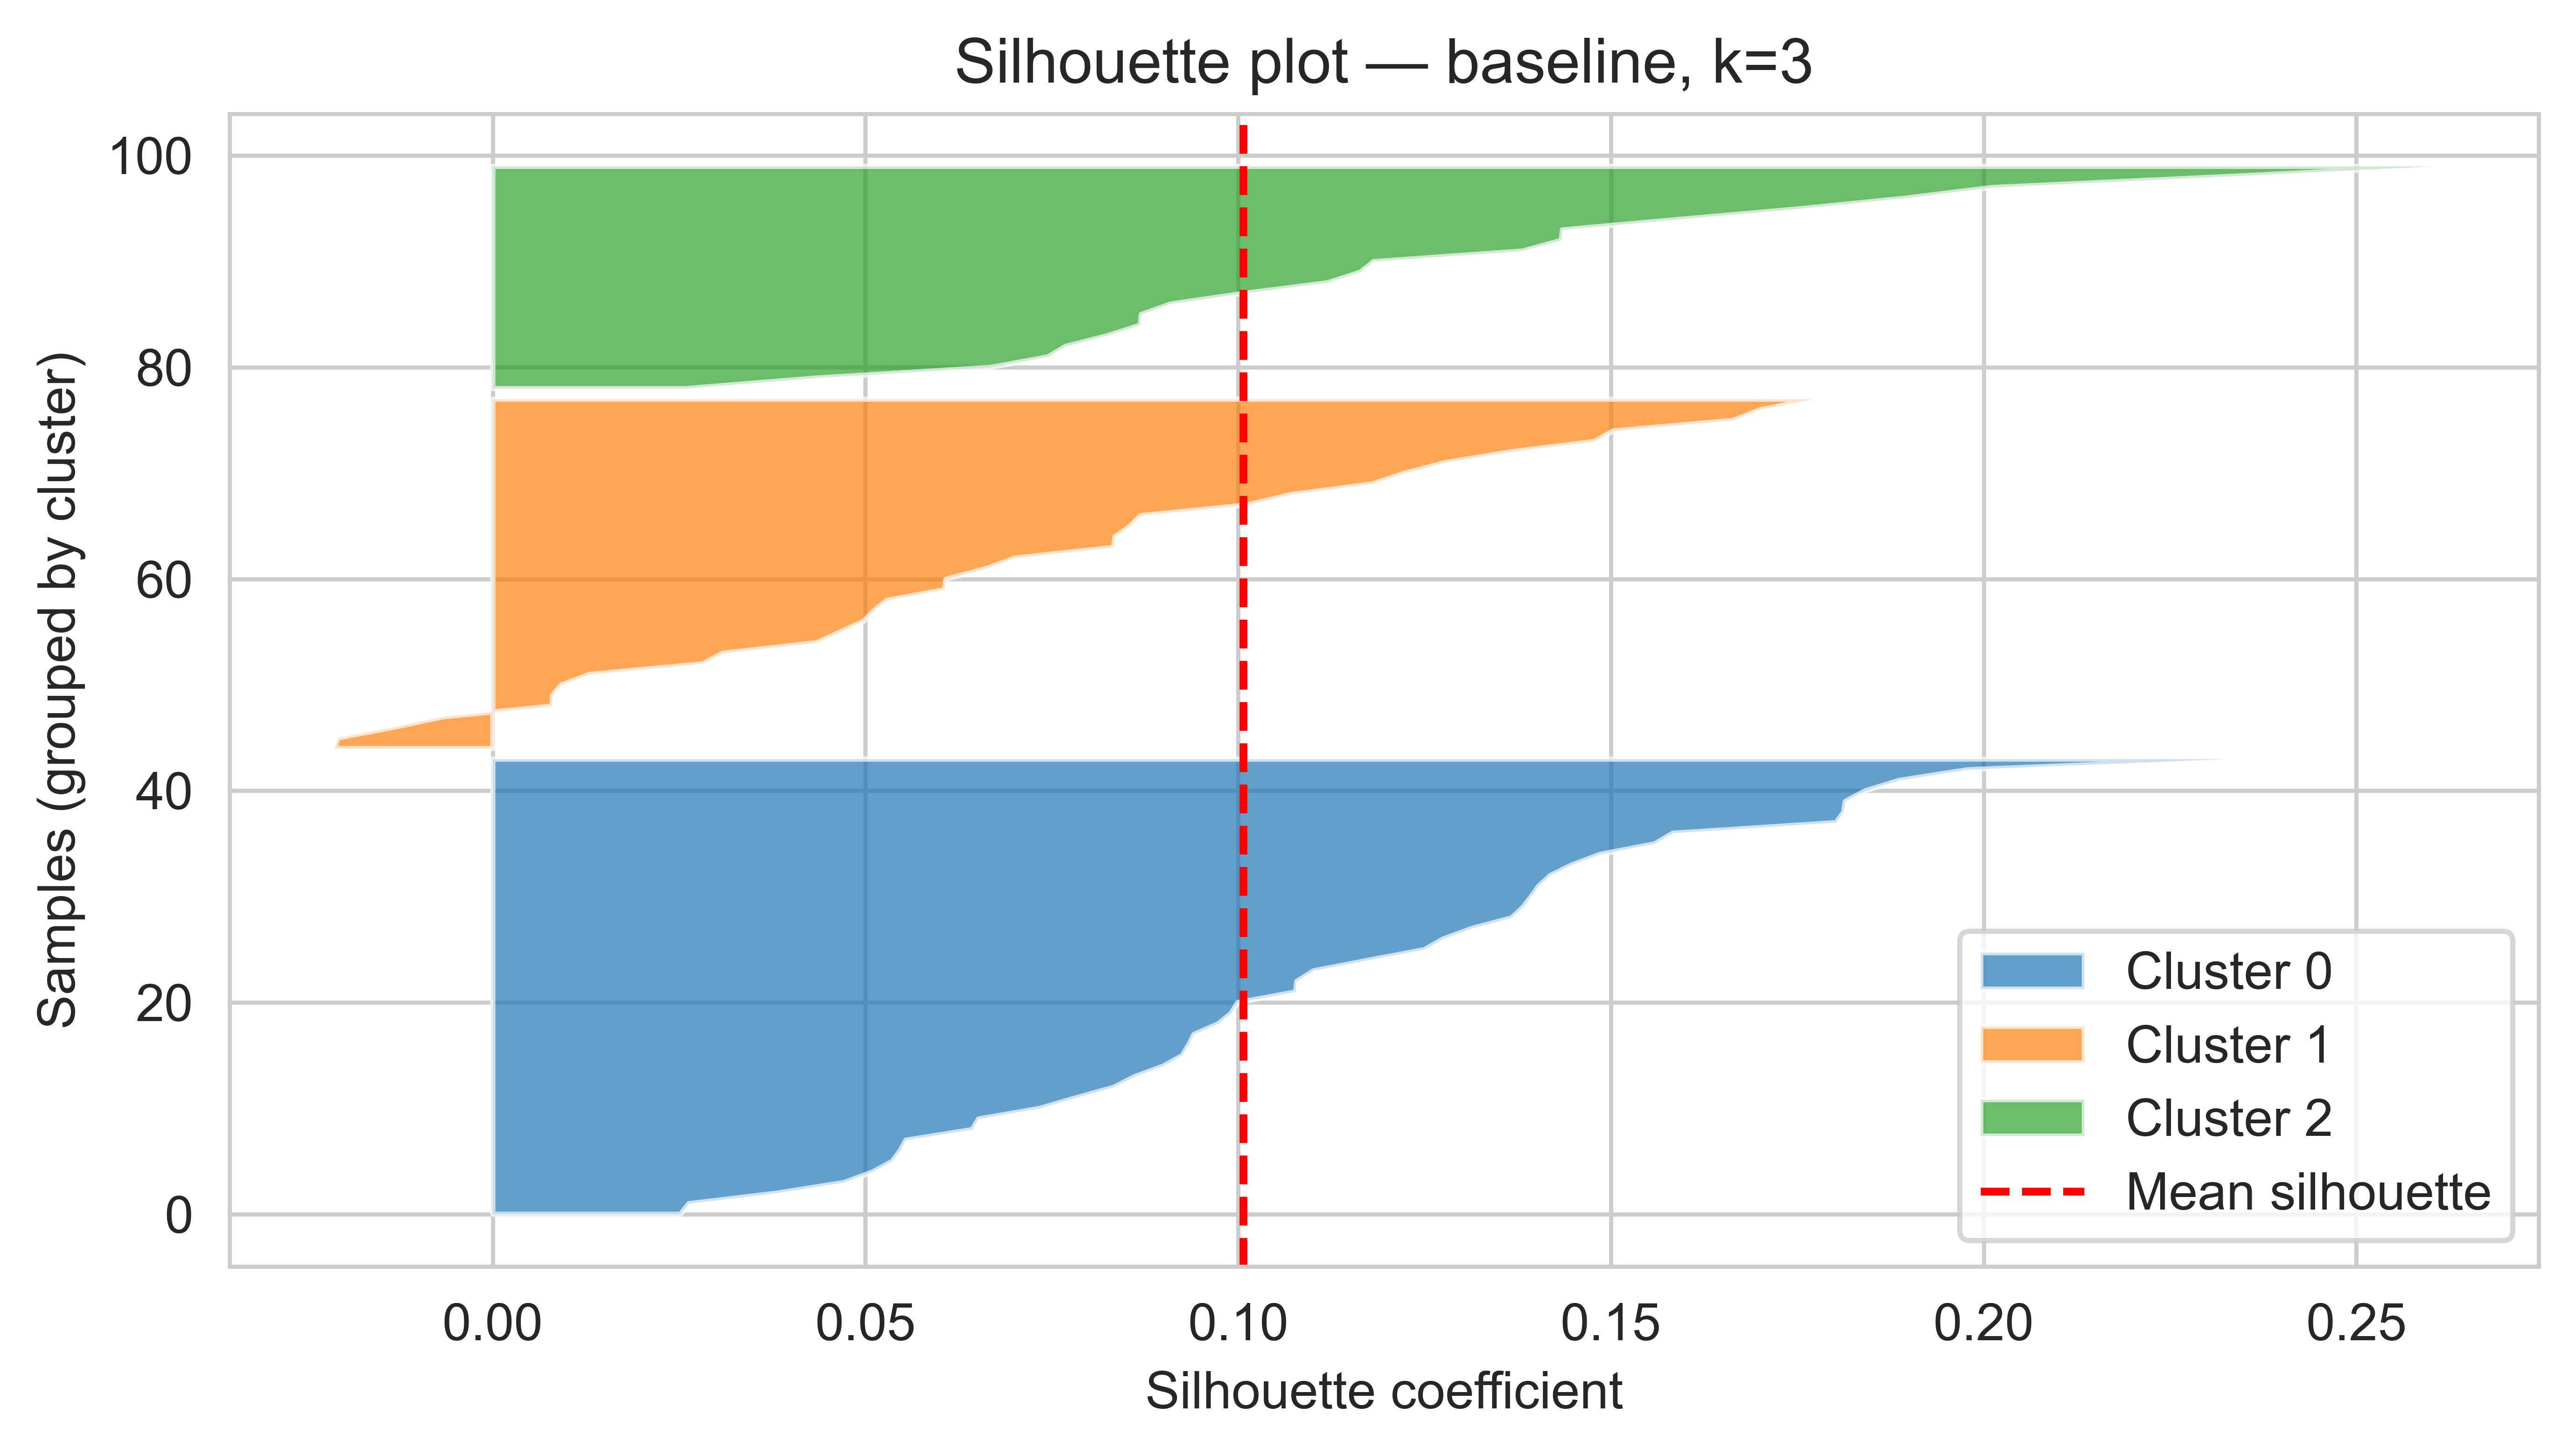

In [13]:
sil_vals = silhouette_samples(results["baseline"]["X"], mob3["cluster"])
best_k_final = results["baseline"]["k"]
fig, ax = plt.subplots(figsize=(7, 4))
y_lower = 0
for i in sorted(mob3["cluster"].unique()):
    vals = np.sort(sil_vals[mob3["cluster"] == i])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7, label=f"Cluster {i}")
    y_lower = y_upper
ax.axvline(sil_vals.mean(), color="red", linestyle="--", label="Mean silhouette")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Samples (grouped by cluster)")
ax.set_title(f"Silhouette plot — baseline, k={best_k_final}")
ax.legend()
plt.tight_layout()
plt.savefig("silhouette_plot_baseline.png", dpi=800)
plt.show()

## Standardized profile heatmap
Z-score of each cluster's mean relative to the overall mean, for numeric features.

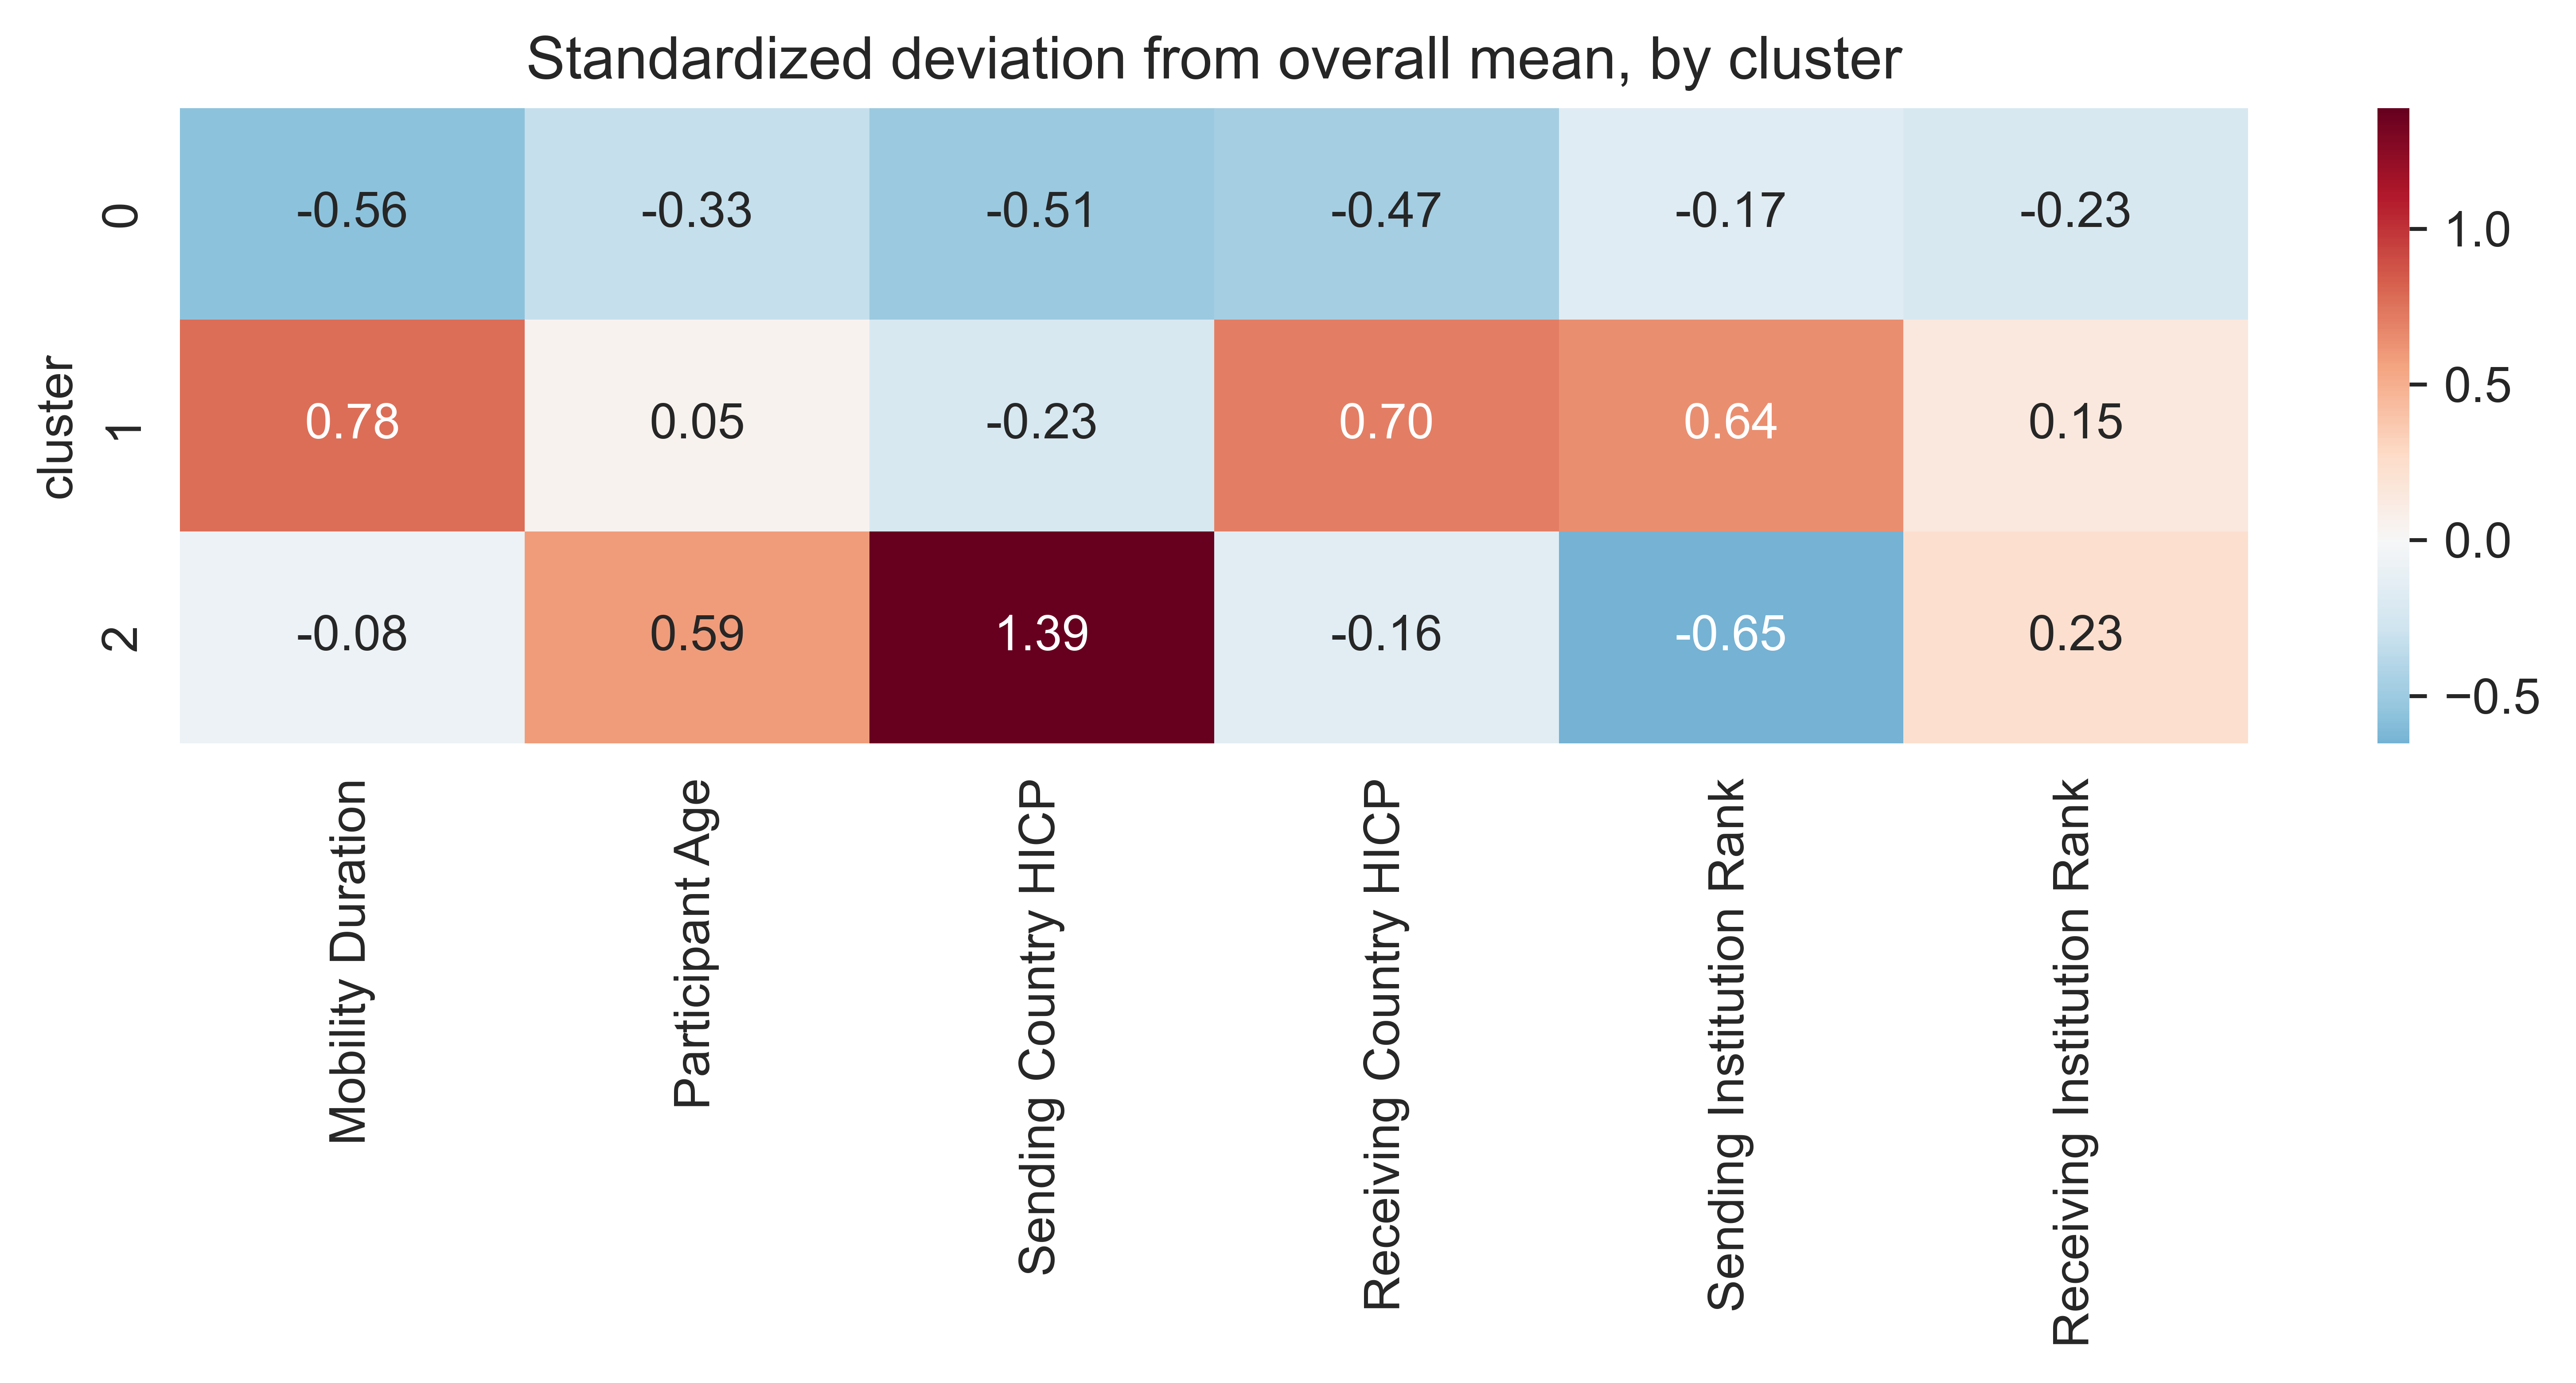

In [14]:
z_profile = (mob3.groupby("cluster")[student_num_cols].mean() - mob3[student_num_cols].mean()) / mob3[student_num_cols].std()

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(z_profile, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Standardized deviation from overall mean, by cluster")
plt.tight_layout()
plt.show()

## Cluster centroids table

In [28]:
centroid_num = mob3.groupby("cluster")[student_num_cols].mean().round(2)
centroid_num.style.background_gradient(cmap=maroon_cmap, axis=0).format("{:.2f}").set_caption("Centroids — numeric features (original units)")

,Mobility Duration,Participant Age,Sending Country HICP,Receiving Country HICP,Sending Institution Rank,Receiving Institution Rank
cluster,,,,,,
0,117.18,25.66,106.90,106.62,488.48,406.02
1,254.15,27.71,108.24,111.72,727.76,517.76
2,166.32,30.59,115.92,107.96,345.27,541.68


In [16]:
cat_centroid_rows = {}
for feat in student_cat_cols:
    row = {}
    for cl in sorted(mob3["cluster"].unique()):
        vc = mob3.loc[mob3["cluster"] == cl, feat].value_counts(normalize=True)
        row[cl] = f"{vc.index[0]} ({vc.iloc[0]:.0%})"
    cat_centroid_rows[feat] = row

df_cat_centroids = pd.DataFrame(cat_centroid_rows).T
df_cat_centroids.columns.name = "cluster"
df_cat_centroids.style.set_caption("Centroids — categorical features (most frequent category, share)")

cluster,0,1,2
Participant Gender,Female (39%),Other (44%),Female (50%)
Fewer Opportunities,No (89%),No (79%),No (86%)
Education Level,Short Cycle (34%),PhD (32%),Short Cycle (32%)
Field of Education,Biology (14%),Business Administration (18%),Law (18%)


## Cluster size
Count of observations per cluster, useful for correctly interpreting η² and Cramér’s V results 

In [17]:
mob3["cluster"].value_counts().sort_index()

cluster
0    44
1    34
2    22
Name: count, dtype: int64

## Statistical tests across clusters
Eta squared method for numeric features.

In [ ]:


def eta_squared(*groups):
    all_data = np.concatenate(groups)
    grand_mean = all_data.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total = sum((all_data - grand_mean)**2)
    return ss_between / ss_total

eta_rows = []

for col in eta_cols:
    groups = [
        mob3.loc[mob3["cluster"] == c, col].dropna().values
        for c in sorted(mob3["cluster"].unique())
    ]

    eta2 = eta_squared(*groups)
    _, p_val = stats.f_oneway(*groups)

    eta_rows.append({
        "Feature": col,
        "η²": round(eta2, 4),
        "p-value": p_val
    })

df_eta = (
    pd.DataFrame(eta_rows)
    .sort_values("η²", ascending=False)
    .reset_index(drop=True)
)

df_eta.style.background_gradient(cmap=maroon_cmap, subset=["η²"]).format({"η²": "{:.4f}", "p-value": "{:.2e}"})

,Feature,η²,p-value
0,Sending Country HICP,0.5643,3.15e-18
1,HICP diff,0.4133,5.84e-12
2,Mobility Duration,0.3486,9.34e-10
3,Receiving Country HICP,0.2719,2.07e-07
4,Sending Institution Rank,0.2482,9.78e-07
5,Participant Age,0.1270,1.38e-03
6,Receiving Institution Rank,0.0438,1.14e-01


Cramer's V method for categorical features.

In [19]:
def cramers_v(confusion_matrix):
    chi2, p, dof, expected = stats.chi2_contingency(confusion_matrix)
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    v = np.sqrt(chi2 / (n * (min(r, k) - 1)))
    return v, p

cramers_rows = []

for col in student_cat_cols + ["Academic Year"]:
    ct = pd.crosstab(mob3["cluster"], mob3[col])

    if ct.shape[0] > 1 and ct.shape[1] > 1:
        v, p = cramers_v(ct)
    else:
        v, p = np.nan, np.nan

    cramers_rows.append({
        "Feature": col,
        "Cramér's V": round(v, 4) if not np.isnan(v) else np.nan,
        "p-value": p
    })

df_cramers = (
    pd.DataFrame(cramers_rows)
    .sort_values("Cramér's V", ascending=False)
    .reset_index(drop=True)
)

df_cramers.style.background_gradient(cmap=maroon_cmap, subset=["Cramér's V"]).format({"Cramér's V": "{:.4f}", "p-value": "{:.2e}"})

,Feature,Cramér's V,p-value
0,Field of Education,0.3779,4.35e-01
1,Participant Gender,0.1731,2.00e-01
2,Education Level,0.1495,6.13e-01
3,Academic Year,0.1396,8.66e-01
4,Fewer Opportunities,0.1149,5.17e-01


## Multiple testing correction
When testing many features simultaneously (via η² and Cramér’s V), the risk of false positives increases. We therefore apply FDR correction (Benjamini–Hochberg) to the p‑values in both tables.

In [20]:
from statsmodels.stats.multitest import multipletests

df_eta["significant_FDR"] = multipletests(df_eta["p-value"], alpha=0.05, method="fdr_bh")[0]
df_cramers_valid = df_cramers.dropna(subset=["p-value"]).copy()
df_cramers_valid["significant_FDR"] = multipletests(df_cramers_valid["p-value"], alpha=0.05, method="fdr_bh")[0]
df_cramers = df_cramers.merge(df_cramers_valid[["Feature", "significant_FDR"]], on="Feature", how="left")

print("Significant η² after FDR:")
display(df_eta[["Feature", "η²", "p-value", "significant_FDR"]])

print("\nSignificant Cramér's V after FDR:")
display(df_cramers[["Feature", "Cramér's V", "p-value", "significant_FDR"]])

Significant η² after FDR:


,Feature,η²,p-value,significant_FDR
0,Sending Country HICP,0.5643,3.150991e-18,True
1,HICP diff,0.4133,5.841472e-12,True
2,Mobility Duration,0.3486,9.336521e-10,True
3,Receiving Country HICP,0.2719,2.073605e-07,True
4,Sending Institution Rank,0.2482,9.784302e-07,True
5,Participant Age,0.1270,1.381342e-03,True
6,Receiving Institution Rank,0.0438,1.136434e-01,False



Significant Cramér's V after FDR:


,Feature,Cramér's V,p-value,significant_FDR
0,Field of Education,0.3779,0.435355,False
1,Participant Gender,0.1731,0.199649,False
2,Education Level,0.1495,0.613364,False
3,Academic Year,0.1396,0.866276,False
4,Fewer Opportunities,0.1149,0.516549,False


## Effect size interpretation
Adds qualitative labels to η² and Cramér’s V (per Cohen) to make effect sizes immediately interpretable, especially when statistical significance in mob3 may be misleading.

In [21]:
def interpret_eta2(v):
    if pd.isna(v): return "n/a"
    if v < 0.01: return "negligible"
    if v < 0.06: return "small"
    if v < 0.14: return "medium"
    return "large"

def interpret_cramers_v(v):
    if pd.isna(v): return "n/a"
    if v < 0.10: return "negligible"
    if v < 0.30: return "small"
    if v < 0.50: return "medium"
    return "large"

df_eta["effect_size"] = df_eta["η²"].apply(interpret_eta2)
df_cramers["effect_size"] = df_cramers["Cramér's V"].apply(interpret_cramers_v)

display(df_eta[["Feature", "η²", "effect_size", "significant_FDR"]])
display(df_cramers[["Feature", "Cramér's V", "effect_size", "significant_FDR"]])

,Feature,η²,effect_size,significant_FDR
0,Sending Country HICP,0.5643,large,True
1,HICP diff,0.4133,large,True
2,Mobility Duration,0.3486,large,True
3,Receiving Country HICP,0.2719,large,True
4,Sending Institution Rank,0.2482,large,True
5,Participant Age,0.1270,medium,True
6,Receiving Institution Rank,0.0438,small,False


,Feature,Cramér's V,effect_size,significant_FDR
0,Field of Education,0.3779,medium,False
1,Participant Gender,0.1731,small,False
2,Education Level,0.1495,small,False
3,Academic Year,0.1396,small,False
4,Fewer Opportunities,0.1149,small,False


## Combined feature ranking
“Combines η² and Cramér’s V into a unified ranking (both normalized to [0, 1]) to identify which variables most strongly define the clusters, regardless of whether they are numerical or categorical.

In [22]:
combined = pd.concat([
    df_eta.rename(columns={"η²": "effect_value"})[["Feature", "effect_value", "effect_size", "significant_FDR"]].assign(type="numeric (η²)"),
    df_cramers.rename(columns={"Cramér's V": "effect_value"})[["Feature", "effect_value", "effect_size", "significant_FDR"]].assign(type="categorical (Cramér's V)"),
], ignore_index=True).sort_values("effect_value", ascending=False).reset_index(drop=True)

combined.style.background_gradient(cmap=maroon_cmap, subset=["effect_value"]).format({"effect_value": "{:.4f}"})

,Feature,effect_value,effect_size,significant_FDR,type
0,Sending Country HICP,0.5643,large,True,numeric (η²)
1,HICP diff,0.4133,large,True,numeric (η²)
2,Field of Education,0.3779,medium,False,categorical (Cramér's V)
3,Mobility Duration,0.3486,large,True,numeric (η²)
4,Receiving Country HICP,0.2719,large,True,numeric (η²)
5,Sending Institution Rank,0.2482,large,True,numeric (η²)
6,Participant Gender,0.1731,small,False,categorical (Cramér's V)
7,Education Level,0.1495,small,False,categorical (Cramér's V)
8,Academic Year,0.1396,small,False,categorical (Cramér's V)
9,Participant Age,0.1270,medium,True,numeric (η²)


## Post-hoc (numerical)
η² indicates how strongly a feature separates the clusters overall, but not which specific cluster pairs differ. Tukey’s HSD on the numerical feature with the highest η² provides the required pairwise comparisons.

In [23]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

top_numeric_feature = df_eta.iloc[0]["Feature"]
print(f"Numeric feature with the strongest effect: {top_numeric_feature}")

tukey = pairwise_tukeyhsd(
    endog=mob3[top_numeric_feature].dropna(),
    groups=mob3.loc[mob3[top_numeric_feature].notna(), "cluster"],
    alpha=0.05
)
print(tukey)

Numeric feature with the strongest effect: Sending Country HICP
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     0      1   1.3418 0.1563 -0.3762  3.0599  False
     0      2   9.0205    0.0  7.0558 10.9851   True
     1      2   7.6786    0.0  5.6199  9.7374   True
----------------------------------------------------


## Post-hoc (categorical)
“Cramér’s V shows overall association, while standardized residuals reveal which cluster–category cells drive it (|residual| > 2 ≈ significant).

Categorical feature with the strongest effect: Field of Education


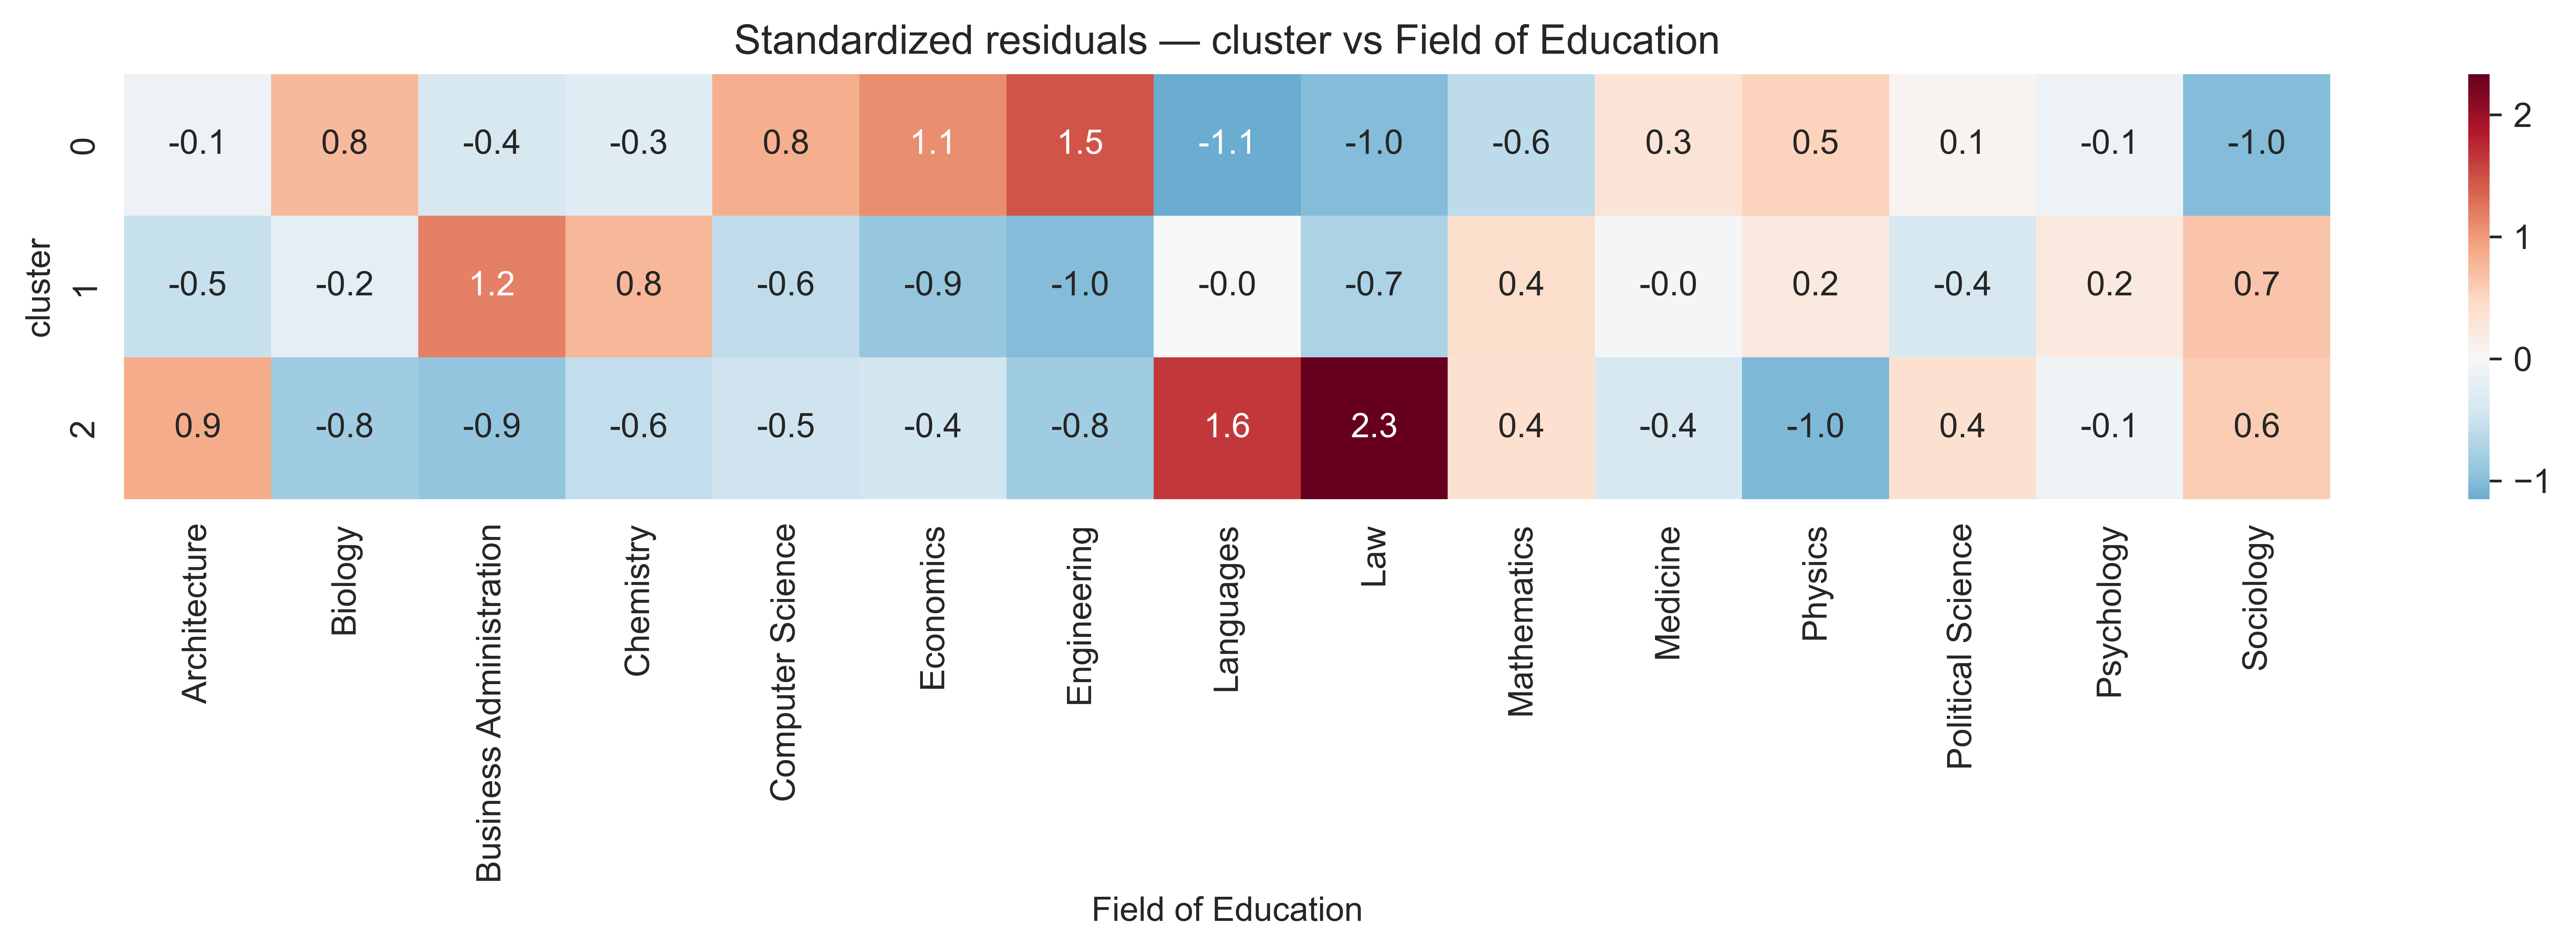

In [24]:
top_cat_feature = df_cramers.dropna(subset=["Cramér's V"]).iloc[0]["Feature"]
print(f"Categorical feature with the strongest effect: {top_cat_feature}")

ct = pd.crosstab(mob3["cluster"], mob3[top_cat_feature])
chi2, p, dof, expected = stats.chi2_contingency(ct)
std_resid = (ct - expected) / np.sqrt(expected)

fig, ax = plt.subplots(figsize=(max(6, ct.shape[1]*0.8), 4))
sns.heatmap(std_resid, annot=True, fmt=".1f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title(f"Standardized residuals — cluster vs {top_cat_feature}")
plt.tight_layout()
plt.show()

## Cluster stability check
Evaluates cluster‑assignment stability by refitting k‑means (same k) on a bootstrap resample and comparing labels via the Adjusted Rand Index (ARI). Values near 1 indicate a robust partition not driven by sampling noise.

c:\Users\User\anaconda3\envs\geo\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\User\anaconda3\envs\geo\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\User\anaconda3\envs\geo\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\User\anaconda3\envs\geo\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known

Mean ARI over 10 bootstrap resamples: 0.398 (± 0.146)


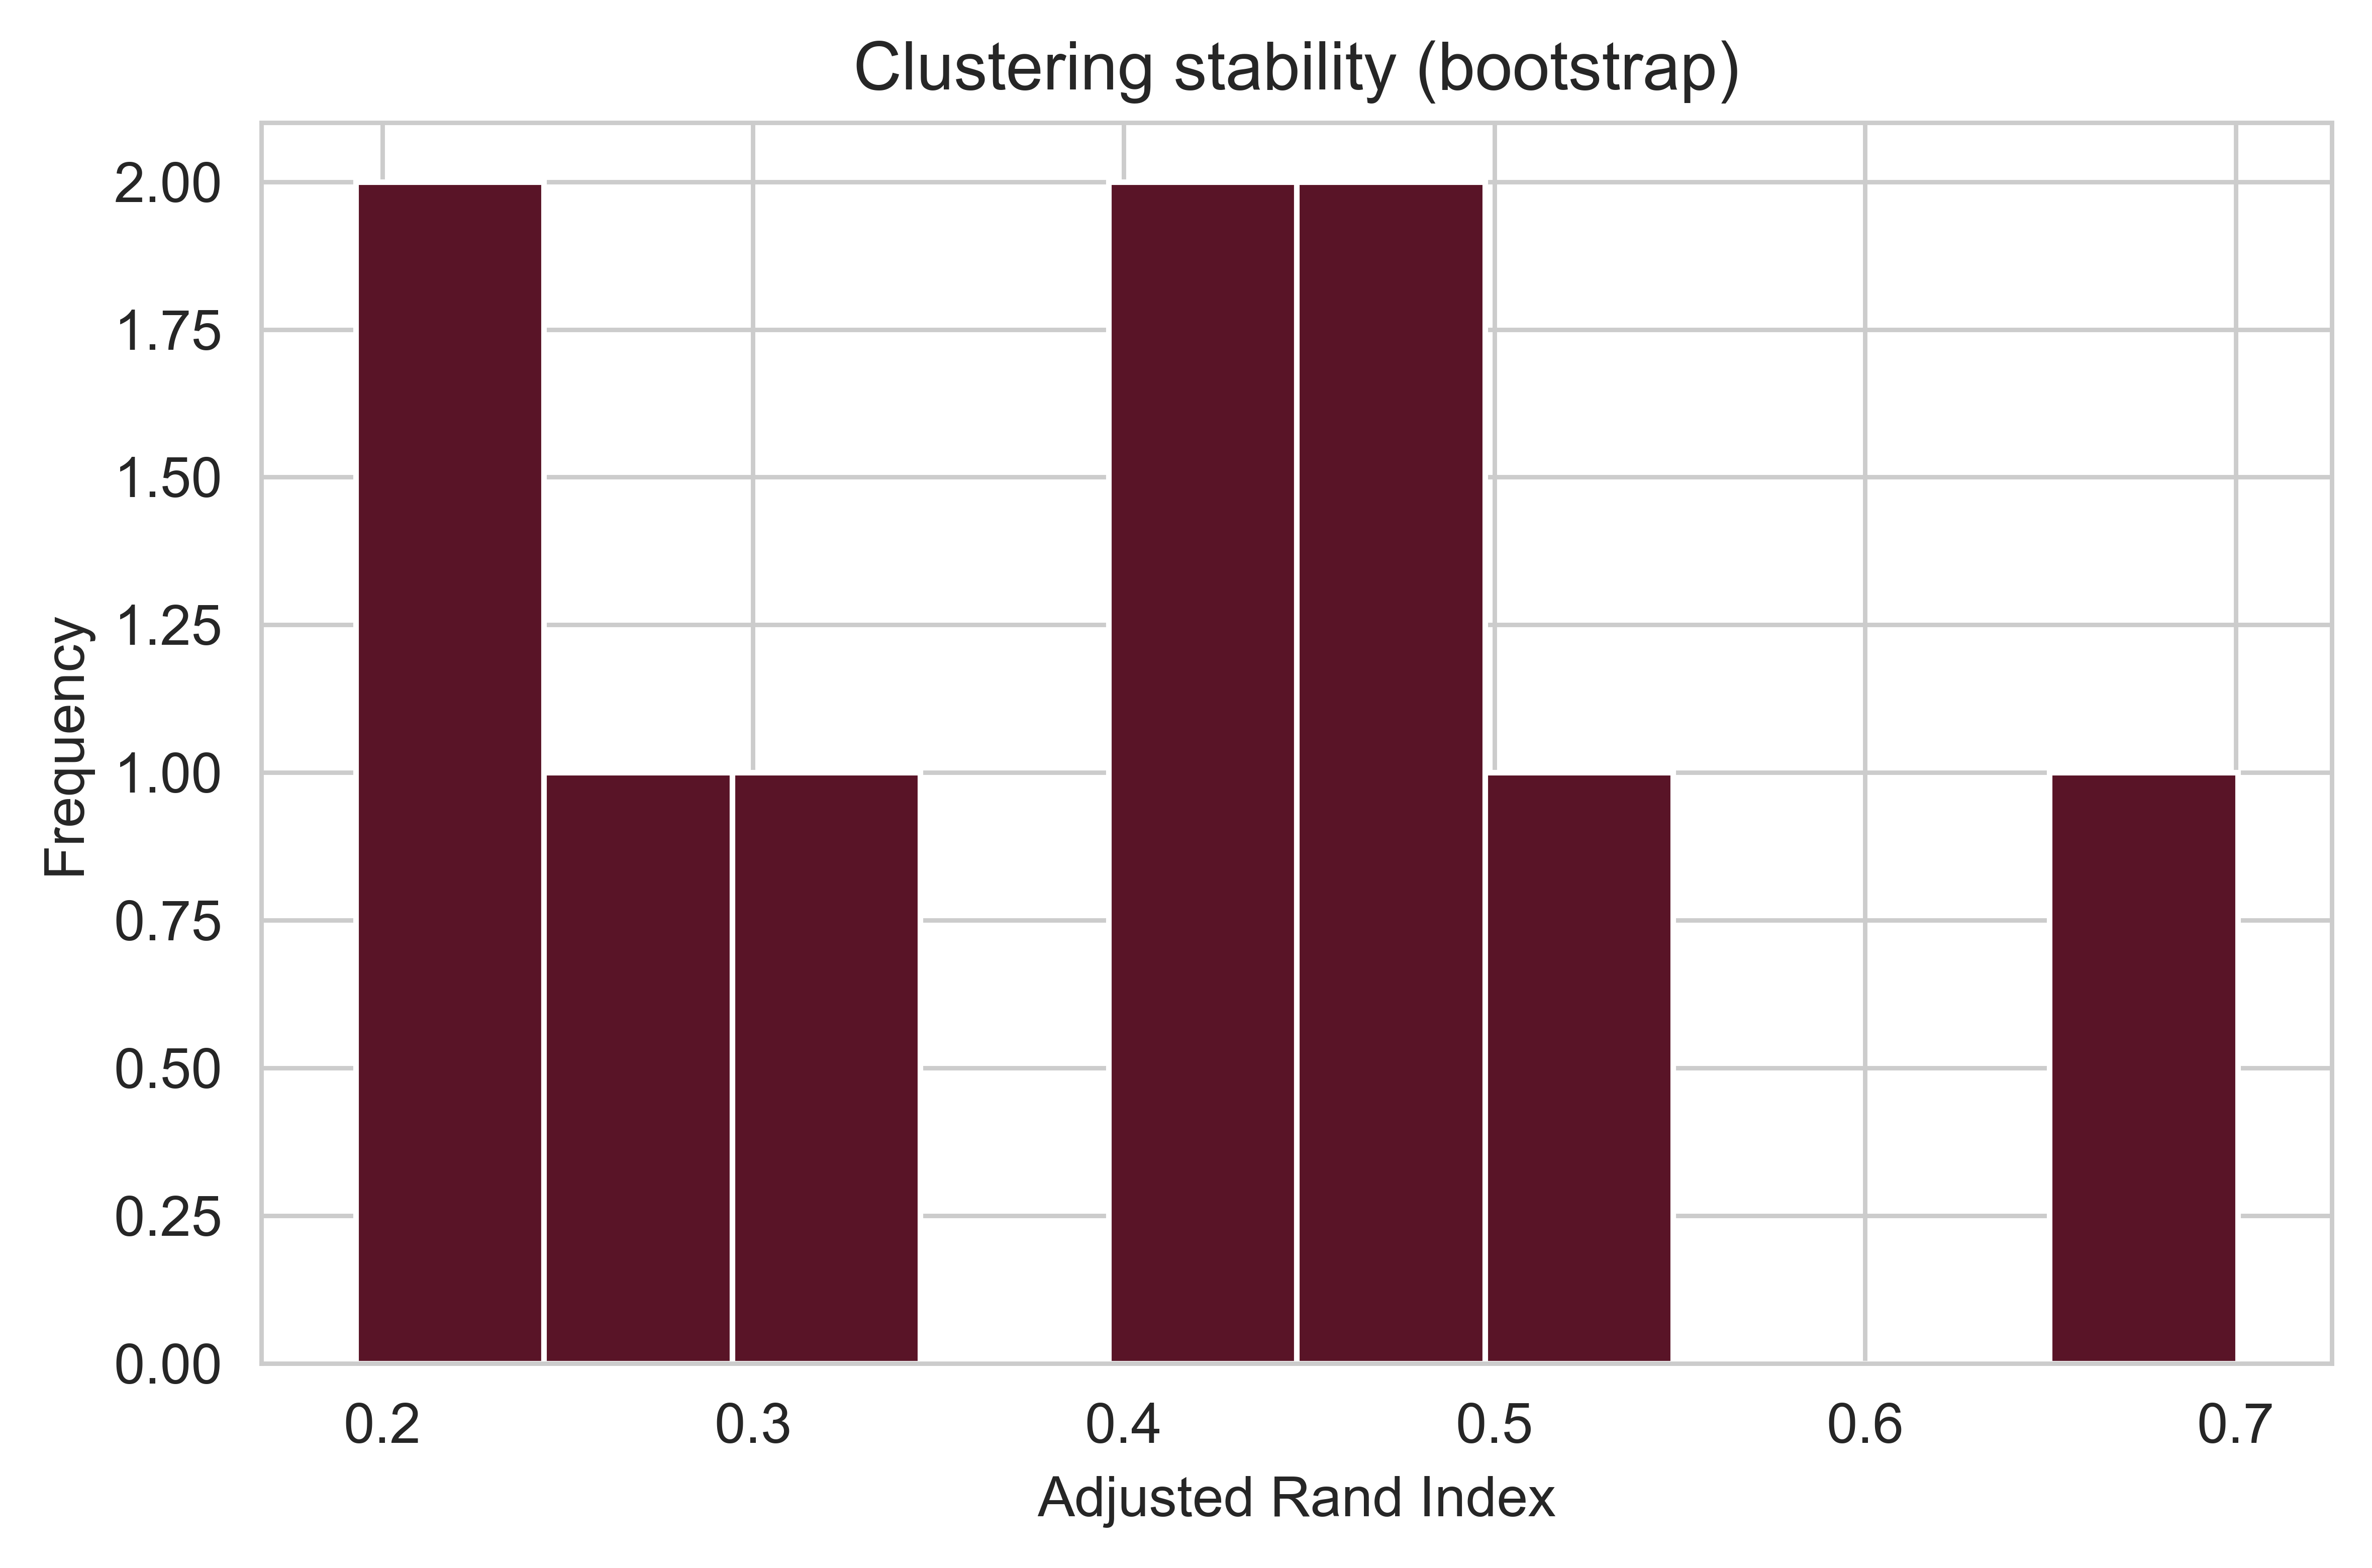

In [29]:
from sklearn.metrics import adjusted_rand_score

n_boot = 10
ari_scores = []
X_best = results["baseline"]["X"]
k_best = results["baseline"]["k"]
labels_orig = mob3["cluster"].values

rng = np.random.default_rng(42)
for i in range(n_boot):
    idx = rng.choice(len(X_best), size=len(X_best), replace=True)
    km_boot = KMeans(n_clusters=k_best, random_state=i, n_init=10)
    labels_boot = km_boot.fit_predict(X_best[idx])
    ari_scores.append(adjusted_rand_score(labels_orig[idx], labels_boot))

print(f"Mean ARI over {n_boot} bootstrap resamples: {np.mean(ari_scores):.3f} (± {np.std(ari_scores):.3f})")

plt.figure(figsize=(6, 4))
plt.hist(ari_scores, bins=10, color="#591427", edgecolor="white")
plt.xlabel("Adjusted Rand Index")
plt.ylabel("Frequency")
plt.title("Clustering stability (bootstrap)")
plt.tight_layout()
plt.show()